# Poisson Match Predictor & 2025/26 Season Simulator - EPL & Serie A
> A multi-season analysis of the Premier League and Serie A using xG-based Poisson modeling, culminating in a Monte Carlo simulation of the remaining 2025/26 season.
by Isaiah Woram

---
## Part 1 - Setup & Data Collection

In [ ]:
# Cell 1 - Imports & Sanity Check
# Let's make sure all packages are loaded before we do anything

import os
import asyncio
import pandas as pd
import numpy as np
from scipy.stats import poisson
import aiohttp
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import FancyArrowPatch
from itertools import permutations
import warnings
import nest_asyncio
nest_asyncio.apply()
warnings.filterwarnings('ignore')

print('All packages loaded')

All packages loaded!


In [24]:
# Cell 2 - Define Leagues, Seasons, and Colors for Visualization
# I'm focusing on EPL and Serie A, primarily due to their consitently competitive battles for Champions League qualification

leagues = {
    'epl':    'Premier League',
    'seriea': 'Serie A'
}

seasons = {
    '2021': '2021/22',
    '2022': '2022/23',
    '2023': '2023/24',
    '2024': '2024/25',
    '2025': '2025/26'
}

# Official league colors
colors = {
    'Premier League': '#C8102E',
    'Serie A':        '#009246'
}

# Rivalry colors for Poisson charts
rivalry_colors = {
    'home': "#7F40E4FF",
    'away': "#37BC66"
}

print(f'Leagues: {list(leagues.values())}')
print(f'Seasons: {list(seasons.values())}')

Leagues: ['Premier League', 'Serie A']
Seasons: ['2021/22', '2022/23', '2023/24', '2024/25', '2025/26']


In [25]:
# Cell 3 - Load and Combine All Historical CSVs
# Reading all league/season files from our competition_data folder

all_dfs = []

for league_code, league_name in leagues.items():
    for season_code, season_label in seasons.items():
        filepath = f'competition_data/{league_code}_{season_code}.csv'
        if os.path.exists(filepath):
            df = pd.read_csv(filepath, sep=';')
            df['league'] = league_name
            df['season'] = season_label
            all_dfs.append(df)
        else:
            print(f'Missing: {filepath}')

raw_df = pd.concat(all_dfs, ignore_index=True)
print(f'Total rows loaded: {len(raw_df)}')
print(f'Shape: {raw_df.shape}')
raw_df.head()

Total rows loaded: 200
Shape: (200, 14)


,number,team,matches,wins,draws,loses,goals,ga,points,xG,xGA,xPTS,league,season
0,1,Manchester City,38,29,6,3,99,26,93,93.40,25.21,91.88,Premier League,2021/22
1,2,Liverpool,38,28,8,2,94,26,92,93.02,32.73,86.56,Premier League,2021/22
2,3,Chelsea,38,21,11,6,76,33,74,69.30,35.12,73.38,Premier League,2021/22
3,4,Tottenham,38,22,5,11,69,40,71,67.95,43.70,66.09,Premier League,2021/22
4,5,Arsenal,38,22,3,13,61,48,69,63.39,48.39,64.76,Premier League,2021/22


In [26]:
# Cell 4 - Clean and Cast Data Types
# Renaming columns and enforcing correct data types below!

raw_df = raw_df.rename(columns={
    'number': 'position',
    'ga':     'goals_against'
})

num_cols = ['position', 'matches', 'wins', 'draws', 'loses',
            'goals', 'goals_against', 'points', 'xG', 'xGA', 'xPTS']
raw_df[num_cols] = raw_df[num_cols].apply(pd.to_numeric, errors='coerce')

print(f'Dtypes:\n{raw_df.dtypes}')
print(f'\nNull values:\n{raw_df.isnull().sum()}')

Dtypes:
position           int64
team                 str
matches            int64
wins               int64
draws              int64
loses              int64
goals              int64
goals_against      int64
points             int64
xG               float64
xGA              float64
xPTS             float64
league               str
season               str
dtype: object

Null values:
position         0
team             0
matches          0
wins             0
draws            0
loses            0
goals            0
goals_against    0
points           0
xG               0
xGA              0
xPTS             0
league           0
season           0
dtype: int64


In [ ]:
# Cell 5 - Feature Engineering!
# Calculating per-match values and performance deltas below

raw_df['goal_difference']    = raw_df['goals'] - raw_df['goals_against']
raw_df['xG_difference']      = raw_df['xG'] - raw_df['xGA']
raw_df['xG_per_match']       = raw_df['xG'] / raw_df['matches']
raw_df['xGA_per_match']      = raw_df['xGA'] / raw_df['matches']
raw_df['pts_per_match']      = raw_df['points'] / raw_df['matches']
raw_df['pts_overperformance'] = raw_df['points'] - raw_df['xPTS']

print('New features created successfully!')
raw_df[['team', 'league', 'season', 'xG_per_match',
        'xGA_per_match', 'pts_overperformance']].head(5)

Features engineered successfully!


,team,league,season,xG_per_match,xGA_per_match,pts_overperformance
0,Manchester City,Premier League,2021/22,2.457895,0.663421,1.12
1,Liverpool,Premier League,2021/22,2.447895,0.861316,5.44
2,Chelsea,Premier League,2021/22,1.823684,0.924211,0.62
3,Tottenham,Premier League,2021/22,1.788158,1.150000,4.91
4,Arsenal,Premier League,2021/22,1.668158,1.273421,4.24


In [28]:
# Cell 6 - Validate Data Load
# Confirming all league/season combos have been loaded with correct team counts

seasons_list = sorted(raw_df['season'].unique())
leagues_list = raw_df['league'].unique()

summary = raw_df.groupby(['league', 'season']).agg(
    teams     = ('team',   'count'),
    avg_xG    = ('xG',     'mean'),
    avg_xGA   = ('xGA',    'mean'),
    avg_pts   = ('points', 'mean'),
    avg_xPTS  = ('xPTS',   'mean')
).round(2).reset_index()

print('Data validation summary:')
display(summary)
print(f'\nTotal unique teams: {raw_df["team"].nunique()}')
print(f'Total rows: {len(raw_df)}')

Data validation summary:


,league,season,teams,avg_xG,avg_xGA,avg_pts,avg_xPTS
0,Premier League,2021/22,20,53.94,53.94,52.60,52.96
1,Premier League,2022/23,20,56.33,56.33,52.65,52.86
2,Premier League,2023/24,20,64.23,64.23,52.90,53.21
3,Premier League,2024/25,20,60.84,60.83,52.35,53.00
4,Premier League,2025/26,20,47.24,47.24,42.70,43.46
5,Serie A,2021/22,20,54.62,54.62,52.10,52.74
6,Serie A,2022/23,20,50.44,50.44,52.00,52.55
7,Serie A,2023/24,20,52.29,52.29,51.40,52.60
8,Serie A,2024/25,20,51.73,51.73,51.60,52.52
9,Serie A,2025/26,20,43.77,43.77,42.90,43.40



Total unique teams: 54
Total rows: 200


---
## Part 2 - EDA of the Last 5 Seasons (2021/22 to 2025/26)
> Using four completed seasons to understand team identity, league trends, and which clubs consistently punch above or below their xG weight.

In [31]:
# Cell 7 - Build Team Strength Ratings Across All Seasons
# Normalizing xG and xGA per match relative to the league average each season

league_avgs = raw_df.groupby(['league', 'season']).agg(
    league_avg_attack  = ('xG_per_match',  'mean'),
    league_avg_defense = ('xGA_per_match', 'mean')
).reset_index()

strength_df = raw_df.merge(league_avgs, on=['league', 'season'])

strength_df['attack_rating']  = (
    strength_df['xG_per_match'] / strength_df['league_avg_attack']
)
strength_df['defense_rating'] = (
    strength_df['xGA_per_match'] / strength_df['league_avg_defense']
)

print('Strength ratings built across all seasons, including 2025/26!')
display(strength_df[['team', 'league', 'season',
                      'attack_rating', 'defense_rating']].sort_values(
    ['league', 'season', 'attack_rating'], ascending=[True, True, False]
).head(5))

Strength ratings built across all seasons, including 2025/26!


,team,league,season,attack_rating,defense_rating
0,Manchester City,Premier League,2021/22,1.731698,0.467410
1,Liverpool,Premier League,2021/22,1.724653,0.606836
2,Chelsea,Premier League,2021/22,1.284868,0.651148
3,Tottenham,Premier League,2021/22,1.259838,0.810227
4,Arsenal,Premier League,2021/22,1.175293,0.897183


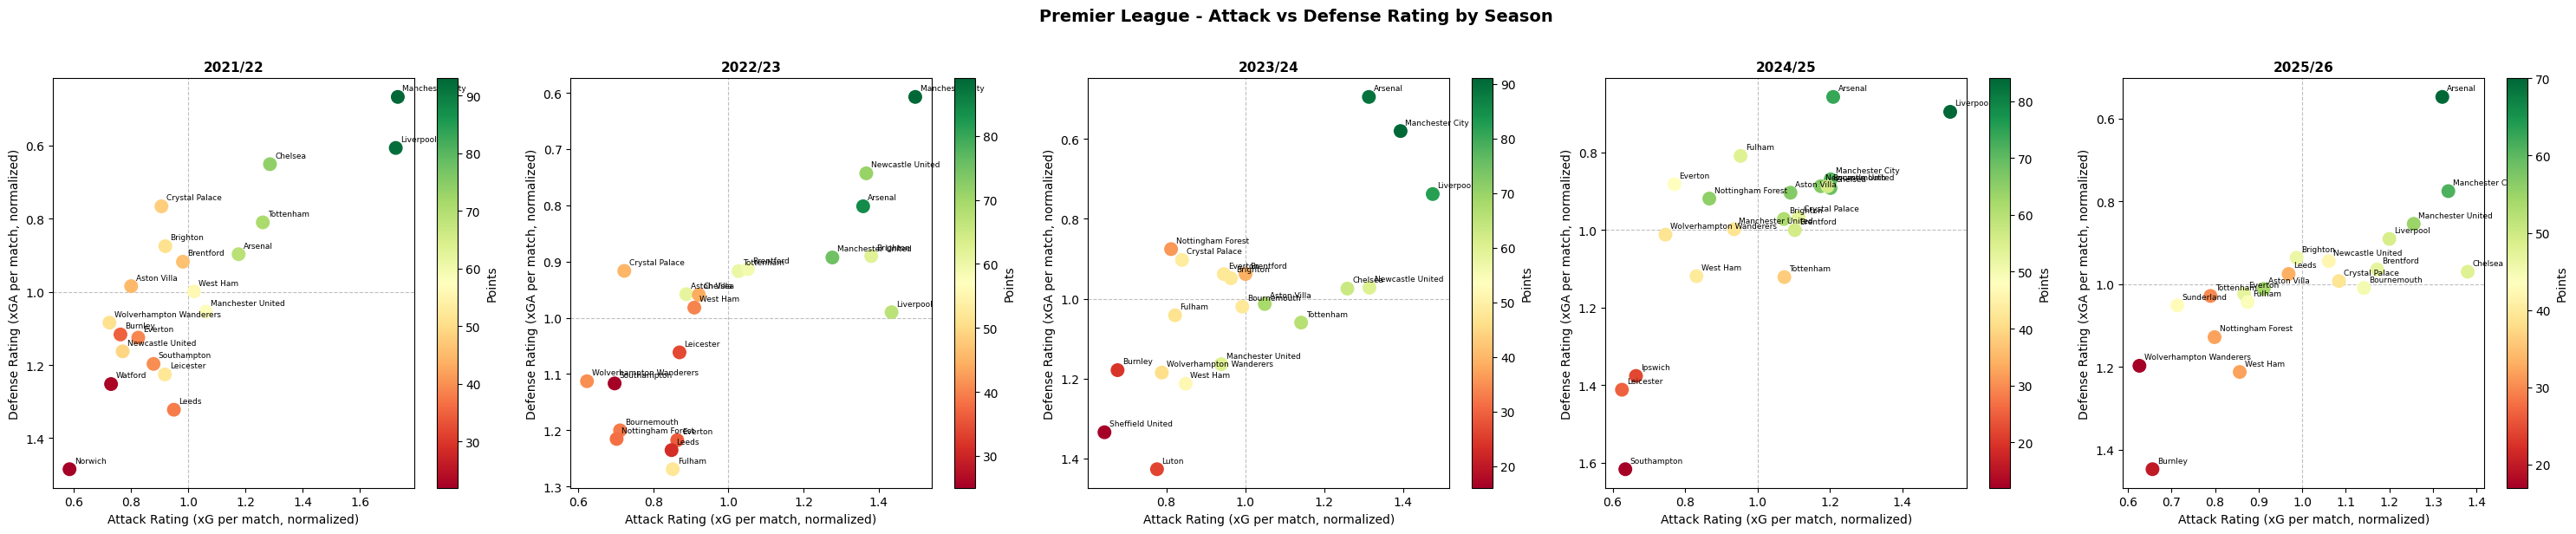

Saved to outputs/strength_premier_league.png


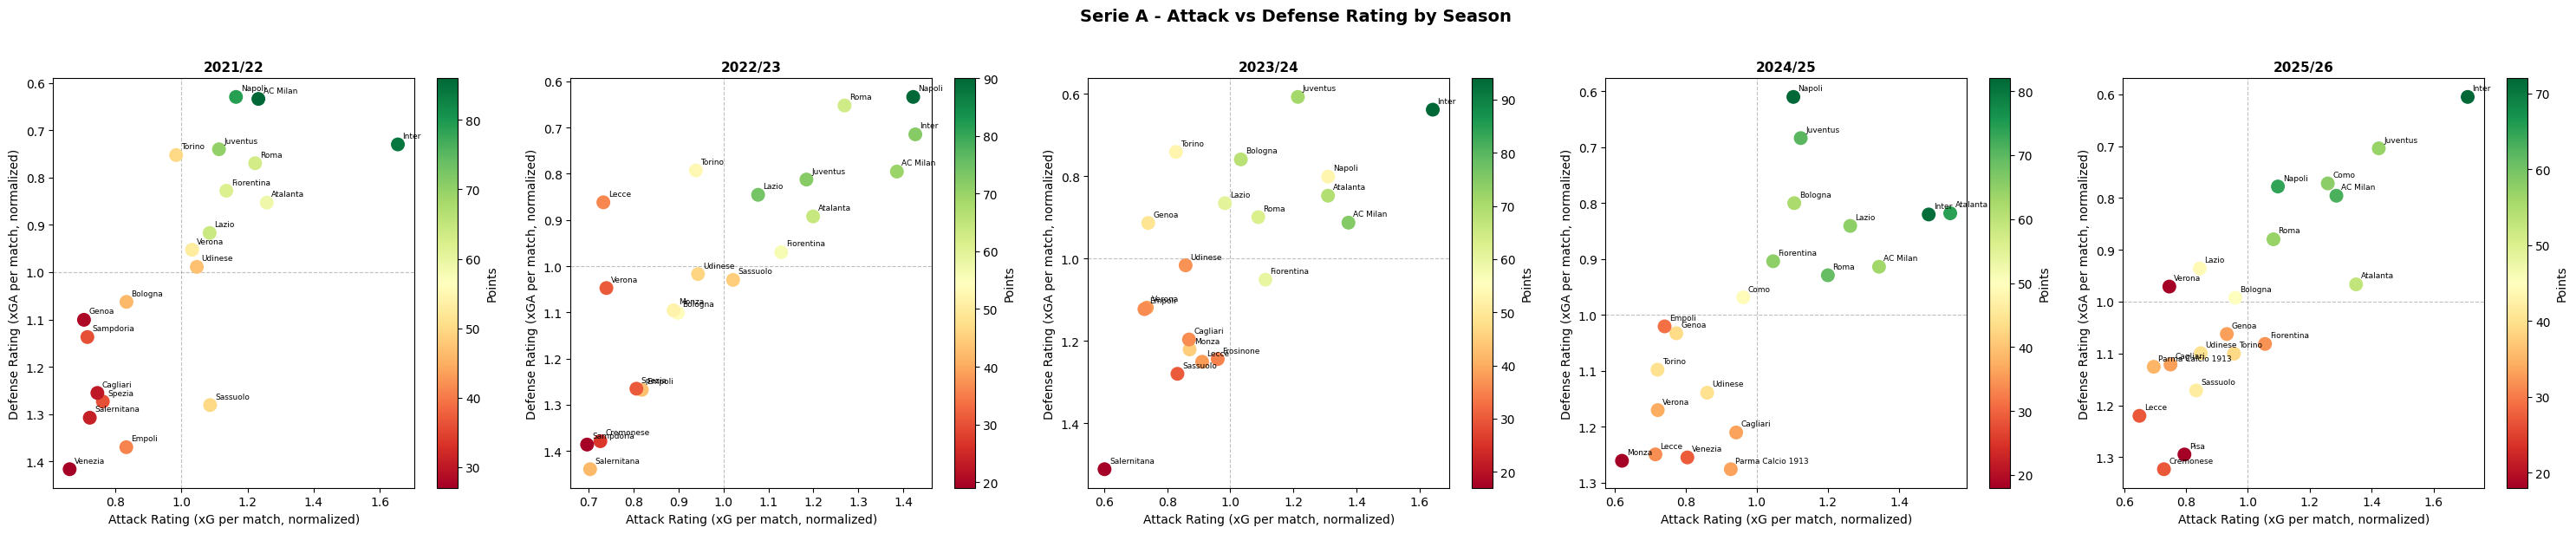

Saved to outputs/strength_serie_a.png


In [ ]:
# Cell 8 - Attack vs Defense Rating Scatter (Last 5 Seasons)
# Each dot is a team - color = points that season, inverted Y axis means better defense = higher up

for league in leagues_list:
    fig, axes = plt.subplots(1, len(seasons_list),
                              figsize=(6 * len(seasons_list), 6))
    fig.suptitle(f'{league} - Attack vs Defense Rating by Season',
                 fontsize=14, fontweight='bold', y=1.02)

    for ax, season in zip(axes, seasons_list):
        group = strength_df[
            (strength_df['league'] == league) &
            (strength_df['season'] == season)
        ].copy()

        ax.axhline(1, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.axvline(1, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

        sc = ax.scatter(
            group['attack_rating'],
            group['defense_rating'],
            c=group['points'],
            cmap='RdYlGn',
            s=110, zorder=3,
            vmin=group['points'].min(),
            vmax=group['points'].max()
        )
        plt.colorbar(sc, ax=ax, label='Points')

        for _, row in group.iterrows():
            ax.annotate(
                row['team'],
                (row['attack_rating'], row['defense_rating']),
                fontsize=6.5, ha='left', va='bottom',
                xytext=(4, 4), textcoords='offset points'
            )

        ax.set_title(season, fontsize=11, fontweight='bold')
        ax.set_xlabel('Attack Rating (xG per match, normalized)')
        ax.set_ylabel('Defense Rating (xGA per match, normalized)')
        ax.invert_yaxis()

    plt.tight_layout()
    filename = f"outputs/strength_{league.lower().replace(' ', '_')}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved to {filename}')

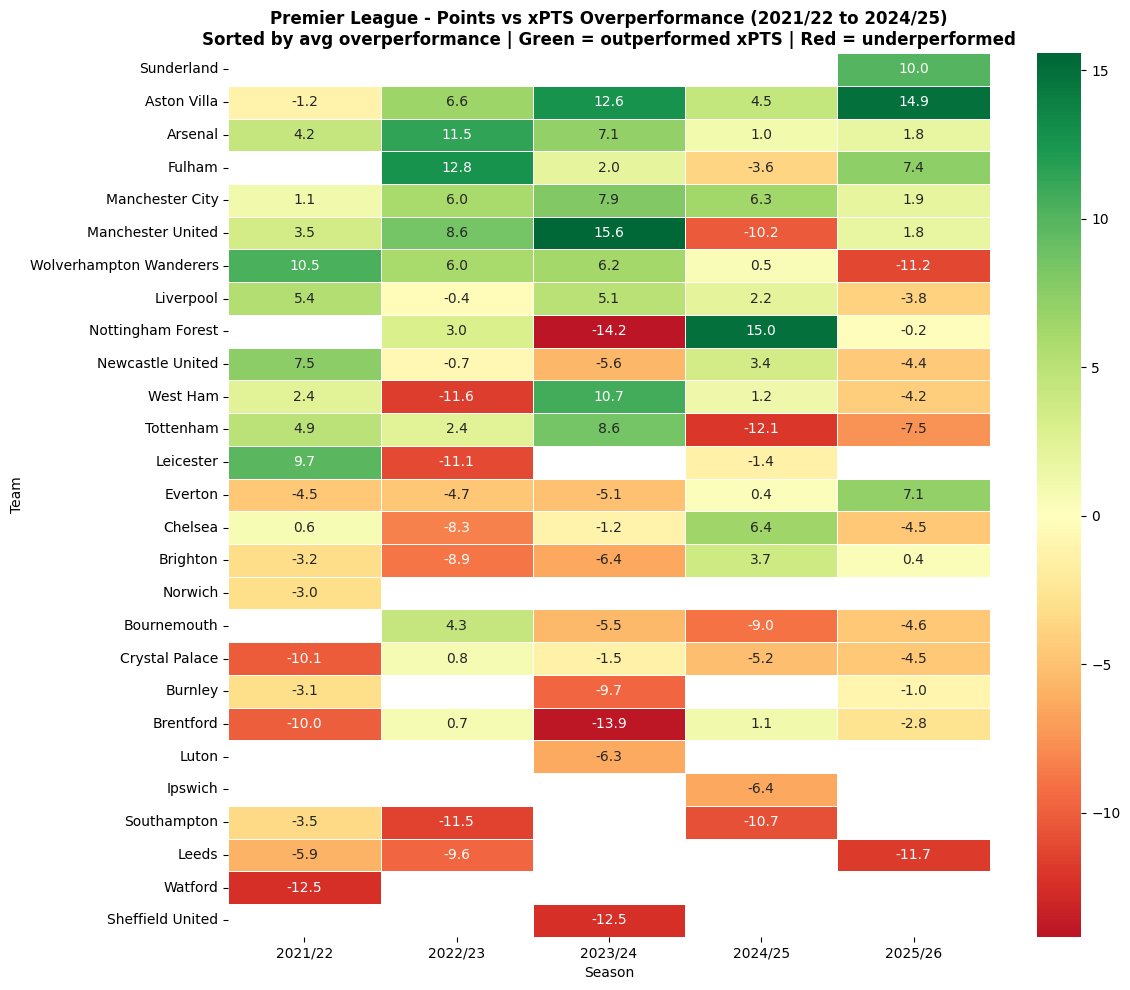

Saved to outputs/xpts_heatmap_premier_league.png


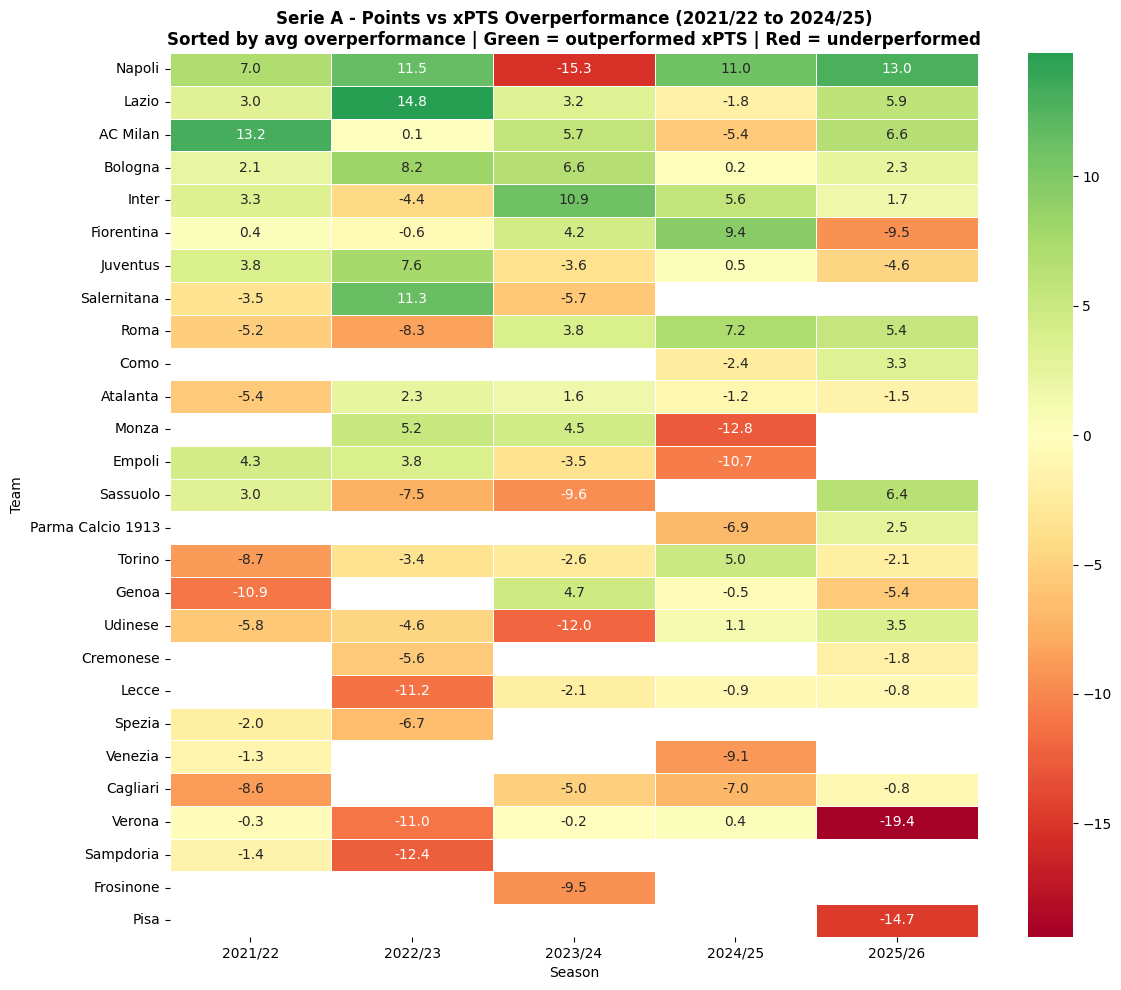

Saved to outputs/xpts_heatmap_serie_a.png


In [ ]:
# Cell 9 - Points vs xPTS Overperformance Heatmap (Last 5 Seasons)
# Green = outperformed xPTS (luck/clinical finishing), Red = underperformed

for league in leagues_list:
    league_data = strength_df[strength_df['league'] == league].copy()

    pivot = league_data.pivot_table(
        index='team',
        columns='season',
        values='pts_overperformance'
    )
    pivot = pivot[seasons_list]
    pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(
        pivot,
        cmap='RdYlGn',
        center=0,
        annot=True,
        fmt='.1f',
        linewidths=0.5,
        ax=ax
    )
    ax.set_title(
        f'{league} - Points vs xPTS Overperformance (2021/22 to 2024/25)\n'
        f'Sorted by avg overperformance | Green = outperformed xPTS | Red = underperformed',
        fontsize=12, fontweight='bold'
    )
    ax.set_xlabel('Season')
    ax.set_ylabel('Team')

    plt.tight_layout()
    filename = f"outputs/xpts_heatmap_{league.lower().replace(' ', '_')}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved to {filename}')

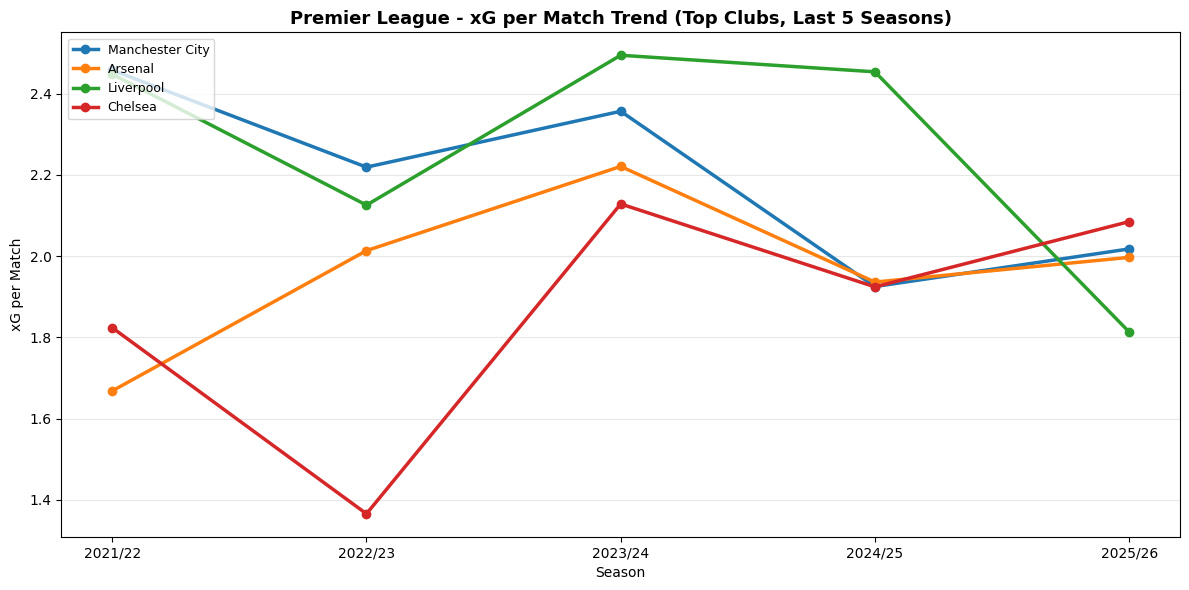

Saved to outputs/xg_trend_premier_league.png


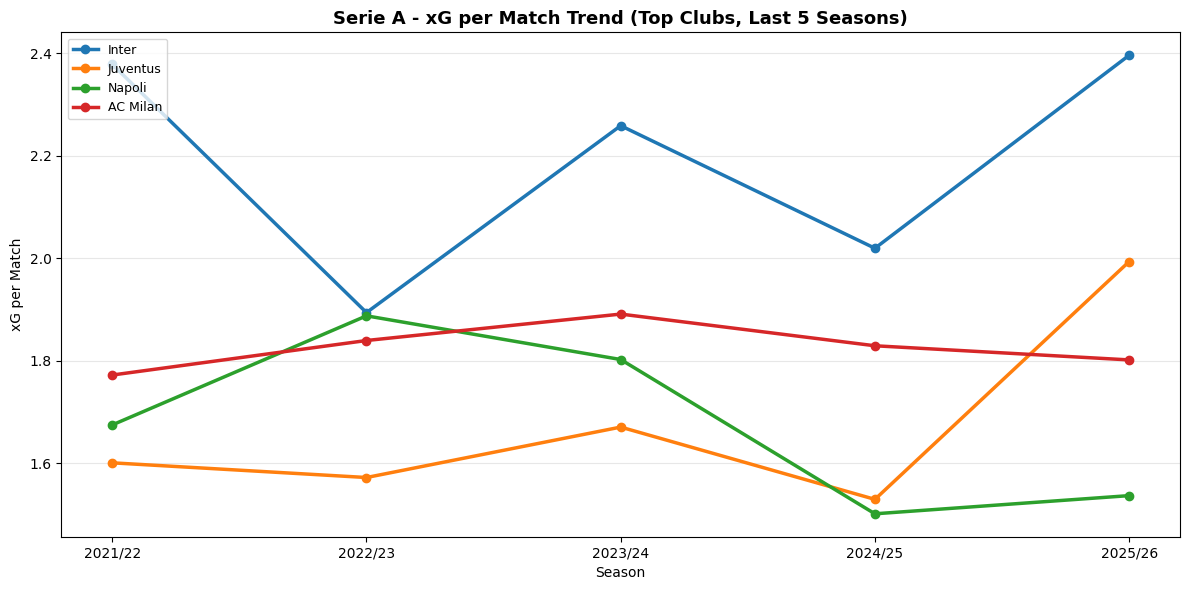

Saved to outputs/xg_trend_serie_a.png


In [ ]:
# Cell 10 - xG per Match Trend for Top Clubs (Last 5 Seasons)
# We can also visualize how attacking output has evolved season over season

top_clubs = {
    'Premier League': ['Manchester City', 'Arsenal', 'Liverpool', 'Chelsea'],
    'Serie A':        ['Inter',           'Juventus', 'Napoli',   'AC Milan']
}

for league, clubs in top_clubs.items():
    fig, ax = plt.subplots(figsize=(12, 6))

    for club in clubs:
        club_data = strength_df[
            (strength_df['team'] == club) &
            (strength_df['league'] == league)
        ].sort_values('season')

        if club_data.empty:
            continue

        ax.plot(
            club_data['season'],
            club_data['xG_per_match'],
            marker='o', linewidth=2.5, label=club
        )

    ax.set_title(f'{league} - xG per Match Trend (Top Clubs, Last 5 Seasons)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Season')
    ax.set_ylabel('xG per Match')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    filename = f"outputs/xg_trend_{league.lower().replace(' ', '_')}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved to {filename}')

---
## Part 3 - The Poisson Model
> Using xG as a proxy for scoring rate, the Poisson distribution lets us estimate the probability of any scoreline - and with that, any match outcome.

xG per match distribution across all seasons:
count    200.00
mean       1.46
std        0.39
min        0.83
25%        1.14
50%        1.39
75%        1.75
max        2.49
Name: xG_per_match, dtype: float64

Derived values: Low=1.01 | Avg=1.46 | High=1.75 | Elite=2.22


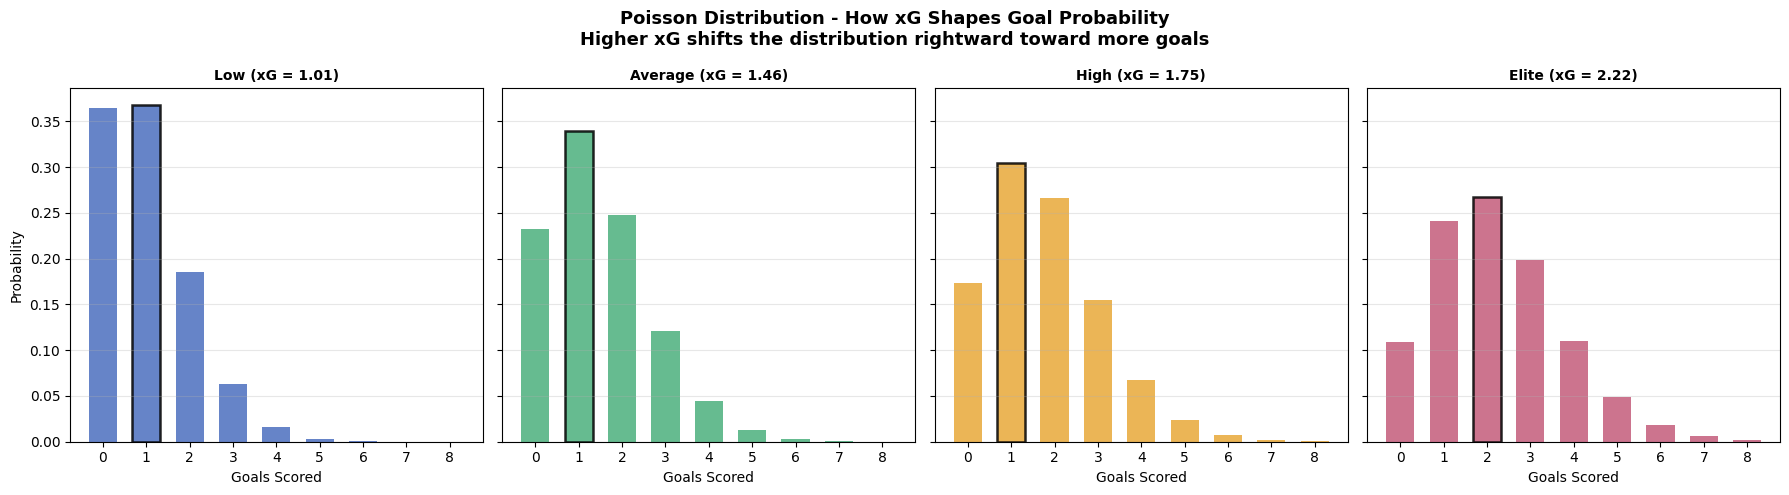

Saved to outputs/poisson_explainer.png


In [ ]:
# Cell 11 - What is the Poisson Distribution?
# Four subplots showing how higher xG shifts goal probability rightward

low_xG   = round(raw_df['xG_per_match'].quantile(0.10), 2)
avg_xG   = round(raw_df['xG_per_match'].mean(), 2)
high_xG  = round(raw_df['xG_per_match'].quantile(0.75), 2)
elite_xG = round(raw_df['xG_per_match'].quantile(0.95), 2)

xg_examples = {
    f'Low (xG = {low_xG})':     (low_xG,   '#4B6FBF'),
    f'Average (xG = {avg_xG})': (avg_xG,   '#4BAF7D'),
    f'High (xG = {high_xG})':   (high_xG,  '#E8A838'),
    f'Elite (xG = {elite_xG})': (elite_xG, '#C45C7A')
}

print(f'xG per match distribution across all seasons:')
print(raw_df['xG_per_match'].describe().round(2))
print(f'\nDerived values: Low={low_xG} | Avg={avg_xG} | High={high_xG} | Elite={elite_xG}')

goals_range = range(9)
fig, axes   = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
fig.suptitle(
    'Poisson Distribution - How xG Shapes Goal Probability\n'
    'Higher xG shifts the distribution rightward toward more goals',
    fontsize=13, fontweight='bold'
)

for ax, (label, (mu, color)) in zip(axes, xg_examples.items()):
    probs      = [poisson.pmf(g, mu) for g in goals_range]
    most_likely = max(range(len(probs)), key=lambda i: probs[i])

    bars = ax.bar(list(goals_range), probs, color=color, alpha=0.85, width=0.65)

    # Highlight the most likely scoreline
    bars[most_likely].set_edgecolor('black')
    bars[most_likely].set_linewidth(1.8)

    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('Goals Scored')
    ax.set_xticks(list(goals_range))
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Probability')

plt.tight_layout()
plt.savefig('outputs/poisson_explainer.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/poisson_explainer.png')

In [37]:
# Cell 12 - Build Current Season Strength Ratings (2025/26 only)
# The Monte Carlo runs on this current season's xG data only

current_df = raw_df[raw_df['season'] == '2025/26'].copy()

current_avgs = current_df.groupby('league').agg(
    league_avg_attack  = ('xG_per_match',  'mean'),
    league_avg_defense = ('xGA_per_match', 'mean')
).reset_index()

current_strength = current_df.merge(current_avgs, on='league')

current_strength['attack_rating']  = (
    current_strength['xG_per_match'] / current_strength['league_avg_attack']
)
current_strength['defense_rating'] = (
    current_strength['xGA_per_match'] / current_strength['league_avg_defense']
)

print('2025/26 strength ratings built!')
display(current_strength[['team', 'league', 'matches', 'points',
                           'attack_rating', 'defense_rating']].sort_values(
    ['league', 'attack_rating'], ascending=[True, False]
))

2025/26 strength ratings built!


,team,league,matches,points,attack_rating,defense_rating
5,Chelsea,Premier League,31,48,1.379628,0.969948
1,Manchester City,Premier League,30,61,1.335177,0.775253
0,Arsenal,Premier League,32,70,1.321418,0.547742
2,Manchester United,Premier League,31,55,1.255818,0.854214
4,Liverpool,Premier League,31,49,1.199890,0.890581
6,Brentford,Premier League,32,47,1.171906,0.964299
9,Bournemouth,Premier League,32,45,1.141714,1.009064
13,Crystal Palace,Premier League,30,39,1.084376,0.992332
12,Newcastle United,Premier League,31,42,1.060924,0.944277
8,Brighton,Premier League,32,46,0.987031,0.936114


In [38]:
# Cell 13 - Match Simulator and Probability Functions
# Core Poisson engine that we'll use to power Part 4...

def simulate_match(home_team, away_team, league, strength_df,
                   home_advantage=1.1):
    home = strength_df[
        (strength_df['team'] == home_team) &
        (strength_df['league'] == league)
    ]
    away = strength_df[
        (strength_df['team'] == away_team) &
        (strength_df['league'] == league)
    ]
    if home.empty or away.empty:
        return None

    league_avg = home['league_avg_attack'].values[0]

    home_xG = (home['attack_rating'].values[0] *
               away['defense_rating'].values[0] *
               league_avg * home_advantage)

    away_xG = (away['attack_rating'].values[0] *
               home['defense_rating'].values[0] *
               league_avg)

    return round(home_xG, 3), round(away_xG, 3)


def get_match_probabilities(home_xG, away_xG, max_goals=10):
    home_probs = [poisson.pmf(i, home_xG) for i in range(max_goals+1)]
    away_probs = [poisson.pmf(i, away_xG) for i in range(max_goals+1)]

    home_win = draw = away_win = 0
    for h in range(max_goals+1):
        for a in range(max_goals+1):
            prob = home_probs[h] * away_probs[a]
            if h > a:
                home_win += prob
            elif h == a:
                draw     += prob
            else:
                away_win += prob

    return {
        'home_win': round(home_win, 4),
        'draw':     round(draw,     4),
        'away_win': round(away_win, 4)
    }


def simulate_scoreline(home_xG, away_xG):
    home_goals = np.random.poisson(home_xG)
    away_goals = np.random.poisson(away_xG)
    return home_goals, away_goals


print('Simulator functions ready!')

Simulator functions ready!


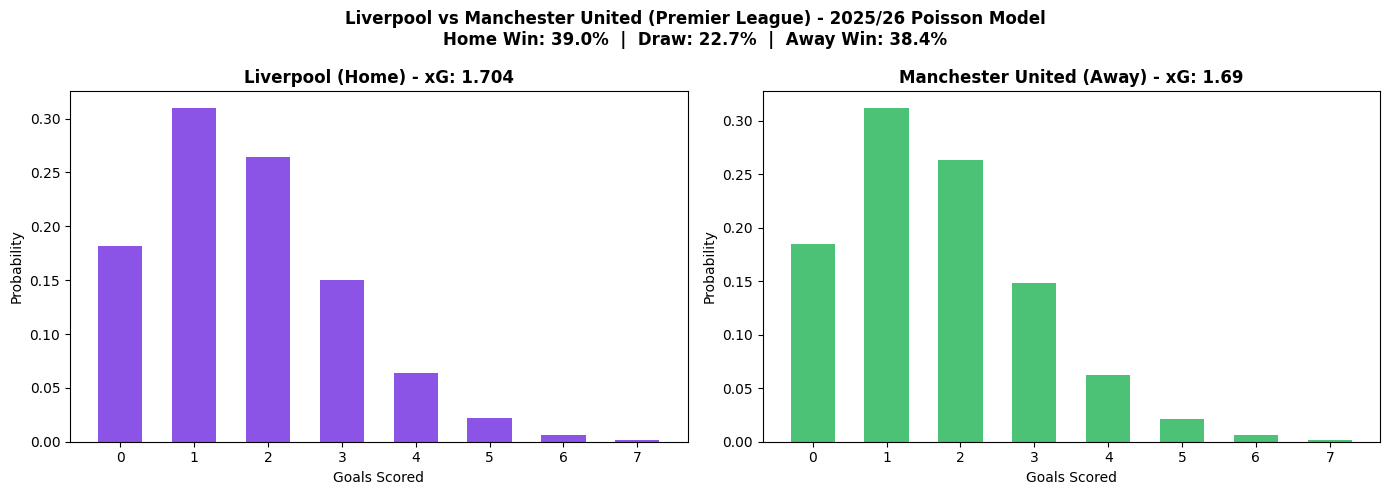

Saved to outputs/rivalry_poisson_premier_league.png


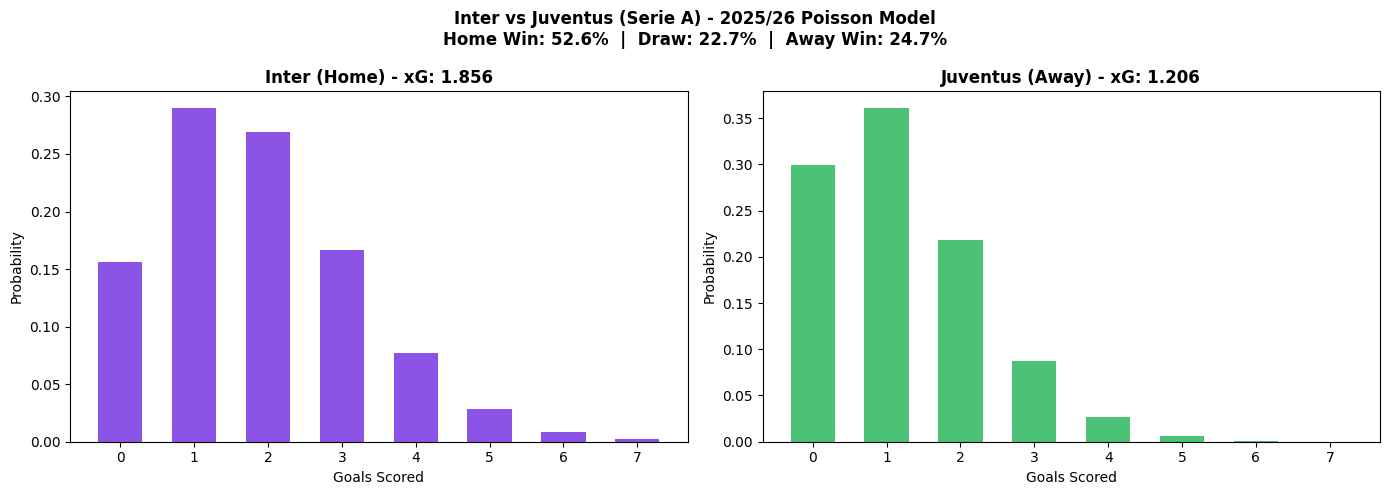

Saved to outputs/rivalry_poisson_serie_a.png


In [39]:
# Cell 14 - Rivalry Poisson Distribution (2025/26)
# Visualizing the goal probability distribution for each league's top rivalry below!

matchups = {
    'Premier League': ('Liverpool',  'Manchester United'),
    'Serie A':        ('Inter',      'Juventus')
}

for league, (home_team, away_team) in matchups.items():
    result = simulate_match(
        home_team, away_team, league, current_strength
    )
    if result is None:
        print(f'Could not simulate {home_team} vs {away_team} - check team names')
        continue

    home_xG, away_xG = result
    goals_range = range(8)
    home_probs  = [poisson.pmf(i, home_xG) for i in goals_range]
    away_probs  = [poisson.pmf(i, away_xG) for i in goals_range]
    probs       = get_match_probabilities(home_xG, away_xG)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f'{home_team} vs {away_team} ({league}) - 2025/26 Poisson Model\n'
        f'Home Win: {probs["home_win"]*100:.1f}%  |  '
        f'Draw: {probs["draw"]*100:.1f}%  |  '
        f'Away Win: {probs["away_win"]*100:.1f}%',
        fontsize=12, fontweight='bold'
    )

    x     = list(goals_range)
    width = 0.6

    axes[0].bar(x, home_probs, width=width,
                color=rivalry_colors['home'], alpha=0.9)
    axes[0].set_title(f'{home_team} (Home) - xG: {home_xG}',
                      fontweight='bold')
    axes[0].set_xlabel('Goals Scored')
    axes[0].set_ylabel('Probability')
    axes[0].set_xticks(x)

    axes[1].bar(x, away_probs, width=width,
                color=rivalry_colors['away'], alpha=0.9)
    axes[1].set_title(f'{away_team} (Away) - xG: {away_xG}',
                      fontweight='bold')
    axes[1].set_xlabel('Goals Scored')
    axes[1].set_ylabel('Probability')
    axes[1].set_xticks(x)

    plt.tight_layout()
    filename = f"outputs/rivalry_poisson_{league.lower().replace(' ', '_')}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved to {filename}')

---
## Part 4 - 2025/26 Monte Carlo Season Simulation
> Using the Poisson model to simulate the remaining fixtures thousands of times, converting results into finish probabilities per position per team.

In [41]:
# Cell 15 - Load 2025/26 Schedule and Split Played vs Remaining
# Matches with a score are already played - blank scores are what we'll simulate to close out the season!

schedule_raw = pd.read_csv('competition_data/schedules_epl_seriea_2025.csv')

print(f'Shape: {schedule_raw.shape}')
print(f'Columns: {list(schedule_raw.columns)}')
print(f'\nNull scores (remaining fixtures): {schedule_raw["Score"].isna().sum()}')
display(schedule_raw[['Home', 'Score', 'Away', 'League']].head(10))

Shape: (760, 13)
Columns: ['Wk', 'Day', 'Date', 'Time', 'Home', 'Score', 'Away', 'Attendance', 'Venue', 'Referee', 'Match Report', 'Notes', 'League']

Null scores (remaining fixtures): 124


,Home,Score,Away,League
0,Liverpool,4–2,Bournemouth,EPL
1,Aston Villa,0–0,Newcastle United,EPL
2,Sunderland,3–0,West Ham United,EPL
3,Brighton,1–1,Fulham,EPL
4,Tottenham Hotspur,3–0,Burnley,EPL
5,Wolves,0–4,Manchester City,EPL
6,Chelsea,0–0,Crystal Palace,EPL
7,Nottingham Forest,3–1,Brentford,EPL
8,Manchester Utd,0–1,Arsenal,EPL
9,Leeds United,1–0,Everton,EPL


In [43]:
# Cell 16 - Parse Schedule Into Played Results and Remaining Fixtures
# We'll extract current points standings from played matches

# Map schedule league names to our league names
league_map = {
    'EPL':    'Premier League',
    'SerieA': 'Serie A'
}

schedule_raw['league'] = schedule_raw['League'].map(league_map)

# Split played vs remaining
played    = schedule_raw[schedule_raw['Score'].notna()].copy()
remaining = schedule_raw[schedule_raw['Score'].isna()].copy()

# Parse scores from played matches
played[['home_goals', 'away_goals']] = (
    played['Score'].str.split('–', expand=True).astype(int)
)

print(f'Played matches: {len(played)}')
print(f'Remaining fixtures: {len(remaining)}')
print(f'\nSample remaining fixtures:')
display(remaining[['Home', 'Away', 'league']].head(10))

Played matches: 636
Remaining fixtures: 124

Sample remaining fixtures:


,Home,Away,league
604,Manchester City,Crystal Palace,Premier League
629,Manchester Utd,Leeds United,Premier League
638,Como,Inter,Serie A
639,Fiorentina,Lazio,Serie A
640,Brentford,Fulham,Premier League
641,Newcastle United,Bournemouth,Premier League
642,Leeds United,Wolves,Premier League
643,Tottenham Hotspur,Brighton,Premier League
644,Chelsea,Manchester Utd,Premier League
645,Everton,Liverpool,Premier League


In [44]:
# Cell 17 - Calculate Current Standings From Played Matches
# Building the live points table to seed the Monte Carlo below!

def calculate_standings(played_df, league):
    league_played = played_df[played_df['league'] == league].copy()
    teams = pd.concat([
        league_played['Home'],
        league_played['Away']
    ]).unique()

    standings = {team: {'points': 0, 'gd': 0, 'gf': 0} for team in teams}

    for _, row in league_played.iterrows():
        h, a = row['Home'], row['Away']
        hg, ag = row['home_goals'], row['away_goals']

        standings[h]['gf'] += hg
        standings[h]['gd'] += hg - ag
        standings[a]['gf'] += ag
        standings[a]['gd'] += ag - hg

        if hg > ag:
            standings[h]['points'] += 3
        elif hg == ag:
            standings[h]['points'] += 1
            standings[a]['points'] += 1
        else:
            standings[a]['points'] += 3

    df = pd.DataFrame(standings).T.reset_index()
    df.columns = ['team', 'points', 'gd', 'gf']
    df['league'] = league
    return df.sort_values('points', ascending=False).reset_index(drop=True)

for league in ['Premier League', 'Serie A']:
    print(f'\nCurrent {league} Standings:')
    display(calculate_standings(played, league))


Current Premier League Standings:


,team,points,gd,gf,league
0,Arsenal,70,38,62,Premier League
1,Manchester City,64,35,63,Premier League
2,Manchester Utd,55,13,56,Premier League
3,Aston Villa,55,5,43,Premier League
4,Liverpool,52,10,52,Premier League
5,Chelsea,48,12,53,Premier League
6,Brentford,47,4,48,Premier League
7,Everton,47,2,39,Premier League
8,Sunderland,46,-3,33,Premier League
9,Brighton,46,6,43,Premier League



Current Serie A Standings:


,team,points,gd,gf,league
0,Inter,72,45,71,Serie A
1,Napoli,66,17,48,Serie A
2,Milan,63,20,47,Serie A
3,Juventus,60,26,55,Serie A
4,Como,58,31,53,Serie A
5,Roma,57,17,45,Serie A
6,Atalanta,53,16,44,Serie A
7,Bologna,48,5,42,Serie A
8,Lazio,44,3,32,Serie A
9,Udinese,43,-4,38,Serie A


In [48]:
# Cell 18 - Normalize Team Names Between the Different Schedule and Strength Datasets
# Team name normalization - mapping schedule names to Understat names

name_map = {
    'Tottenham Hotspur':    'Tottenham',
    'West Ham United':      'West Ham',
    'Wolves':               'Wolverhampton Wanderers',
    'Manchester Utd':       'Manchester United',
    'Milan':                'AC Milan',
    'Leeds United':         'Leeds',
    'Hellas Verona':        'Verona',
    'Parma':                'Parma Calcio 1913'
}

remaining['Home'] = remaining['Home'].replace(name_map)
remaining['Away'] = remaining['Away'].replace(name_map)
played['Home']    = played['Home'].replace(name_map)
played['Away']    = played['Away'].replace(name_map)

# Verify no mismatches remain
schedule_teams = set(
    pd.concat([remaining['Home'], remaining['Away']]).unique()
)
strength_teams = set(current_strength['team'].unique())
still_missing  = schedule_teams - strength_teams

if still_missing:
    print(f'Still unmatched: {still_missing}')
else:
    print('All team names matched successfully - ready to simulate!')

All team names matched successfully - ready to simulate!


In [49]:
# Cell 19 - Monte Carlo Season Simulation (N=10,000)
# Simulating the remaining fixtures 10,000 times and tallying finish positions below!

N_SIMS = 10000

def run_monte_carlo(played_df, remaining_df, league, strength_df, n_sims=10000):
    current = calculate_standings(played_df, league)
    teams   = current['team'].tolist()
    n_teams = len(teams)

    # Tally finish positions across simulations
    finish_counts = {team: [0] * n_teams for team in teams}

    league_remaining = remaining_df[
        remaining_df['league'] == league
    ][['Home', 'Away']].values.tolist()

    for _ in range(n_sims):
        sim_points = current.set_index('team')['points'].to_dict()
        sim_gd     = current.set_index('team')['gd'].to_dict()
        sim_gf     = current.set_index('team')['gf'].to_dict()

        for home_team, away_team in league_remaining:
            if home_team not in sim_points or away_team not in sim_points:
                continue

            result = simulate_match(
                home_team, away_team, league, strength_df
            )
            if result is None:
                continue

            home_xG, away_xG = result
            hg, ag = simulate_scoreline(home_xG, away_xG)

            sim_gf[home_team] += hg
            sim_gf[away_team] += ag
            sim_gd[home_team] += hg - ag
            sim_gd[away_team] += ag - hg

            if hg > ag:
                sim_points[home_team] += 3
            elif hg == ag:
                sim_points[home_team] += 1
                sim_points[away_team] += 1
            else:
                sim_points[away_team] += 3

        # Sort by points, then GD, then GF
        final_table = sorted(
            teams,
            key=lambda t: (sim_points[t], sim_gd[t], sim_gf[t]),
            reverse=True
        )
        for pos, team in enumerate(final_table):
            finish_counts[team][pos] += 1

    # Convert to probabilities
    prob_df = pd.DataFrame(finish_counts).T
    prob_df.columns = [f'P{i+1}' for i in range(n_teams)]
    prob_df = prob_df.div(n_sims)

    # Sort by most likely finish
    prob_df['avg_position'] = prob_df.apply(
        lambda row: sum((i+1) * row[f'P{i+1}'] for i in range(n_teams)), axis=1
    )
    prob_df = prob_df.sort_values('avg_position').drop(columns='avg_position')

    return prob_df


print(f'Running {N_SIMS:,} simulations per league...')

epl_sim = run_monte_carlo(
    played, remaining, 'Premier League', current_strength, N_SIMS
)
print('Premier League done!')

seriea_sim = run_monte_carlo(
    played, remaining, 'Serie A', current_strength, N_SIMS
)
print('Serie A done!')

Running 10,000 simulations per league...
Premier League done!
Serie A done!


In [50]:
# Cell 20 - Display Simulation Results as Finish Probability Tables
# Each cell = probability of that team finishing in that exact position

def style_sim_table(sim_df, league):
    pct_df = (sim_df * 100).round(1)
    styled = pct_df.style.background_gradient(
        cmap='YlGn', axis=None
    ).format('{:.1f}%')
    print(f'\n{league} - 2025/26 Finish Probability Table ({N_SIMS:,} simulations):')
    display(styled)

style_sim_table(epl_sim,    'Premier League')
style_sim_table(seriea_sim, 'Serie A')


Premier League - 2025/26 Finish Probability Table (10,000 simulations):


,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,P17,P18,P19,P20
Arsenal,87.8%,12.2%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
Manchester City,12.2%,86.2%,1.5%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
Manchester United,0.0%,1.4%,72.0%,18.0%,5.7%,2.2%,0.5%,0.2%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
Aston Villa,0.0%,0.1%,13.7%,43.1%,26.9%,10.3%,4.1%,1.2%,0.5%,0.1%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
Liverpool,0.0%,0.0%,10.0%,26.1%,28.8%,19.0%,8.5%,3.9%,2.2%,1.1%,0.4%,0.1%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
Chelsea,0.0%,0.0%,2.5%,9.3%,23.7%,29.2%,15.6%,9.2%,5.0%,2.8%,1.6%,0.8%,0.2%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
Brentford,0.0%,0.0%,0.3%,1.7%,6.0%,12.3%,19.1%,17.9%,14.8%,10.8%,7.2%,5.3%,3.3%,1.2%,0.1%,0.0%,0.0%,0.0%,0.0%,0.0%
Brighton,0.0%,0.0%,0.1%,0.7%,3.4%,9.4%,14.6%,16.5%,15.6%,13.5%,11.2%,7.4%,4.6%,2.6%,0.4%,0.0%,0.0%,0.0%,0.0%,0.0%
Everton,0.0%,0.0%,0.0%,0.5%,2.2%,6.5%,12.0%,14.7%,15.4%,15.6%,12.3%,9.9%,7.0%,3.7%,0.2%,0.0%,0.0%,0.0%,0.0%,0.0%
Bournemouth,0.0%,0.0%,0.0%,0.3%,1.7%,5.7%,11.0%,13.6%,14.7%,13.7%,12.7%,10.9%,8.2%,6.2%,1.2%,0.0%,0.0%,0.0%,0.0%,0.0%



Serie A - 2025/26 Finish Probability Table (10,000 simulations):


,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,P17,P18,P19,P20
Inter,99.8%,0.2%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
Napoli,0.2%,60.5%,25.2%,9.6%,4.0%,0.5%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
AC Milan,0.0%,21.5%,31.7%,25.4%,16.2%,4.7%,0.4%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
Juventus,0.0%,11.2%,27.2%,30.7%,25.0%,5.5%,0.5%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
Como,0.0%,6.5%,14.7%,28.3%,35.5%,13.3%,1.6%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
Roma,0.0%,0.1%,1.2%,5.4%,16.1%,53.9%,23.0%,0.3%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
Atalanta,0.0%,0.0%,0.0%,0.6%,3.2%,22.0%,70.7%,3.1%,0.4%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
Bologna,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,2.5%,46.7%,32.4%,13.7%,4.2%,0.5%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
Lazio,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,1.1%,32.0%,31.2%,22.1%,10.0%,3.0%,0.5%,0.1%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
Udinese,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.2%,13.9%,22.9%,31.8%,20.2%,8.2%,2.1%,0.5%,0.1%,0.0%,0.0%,0.0%,0.0%,0.0%


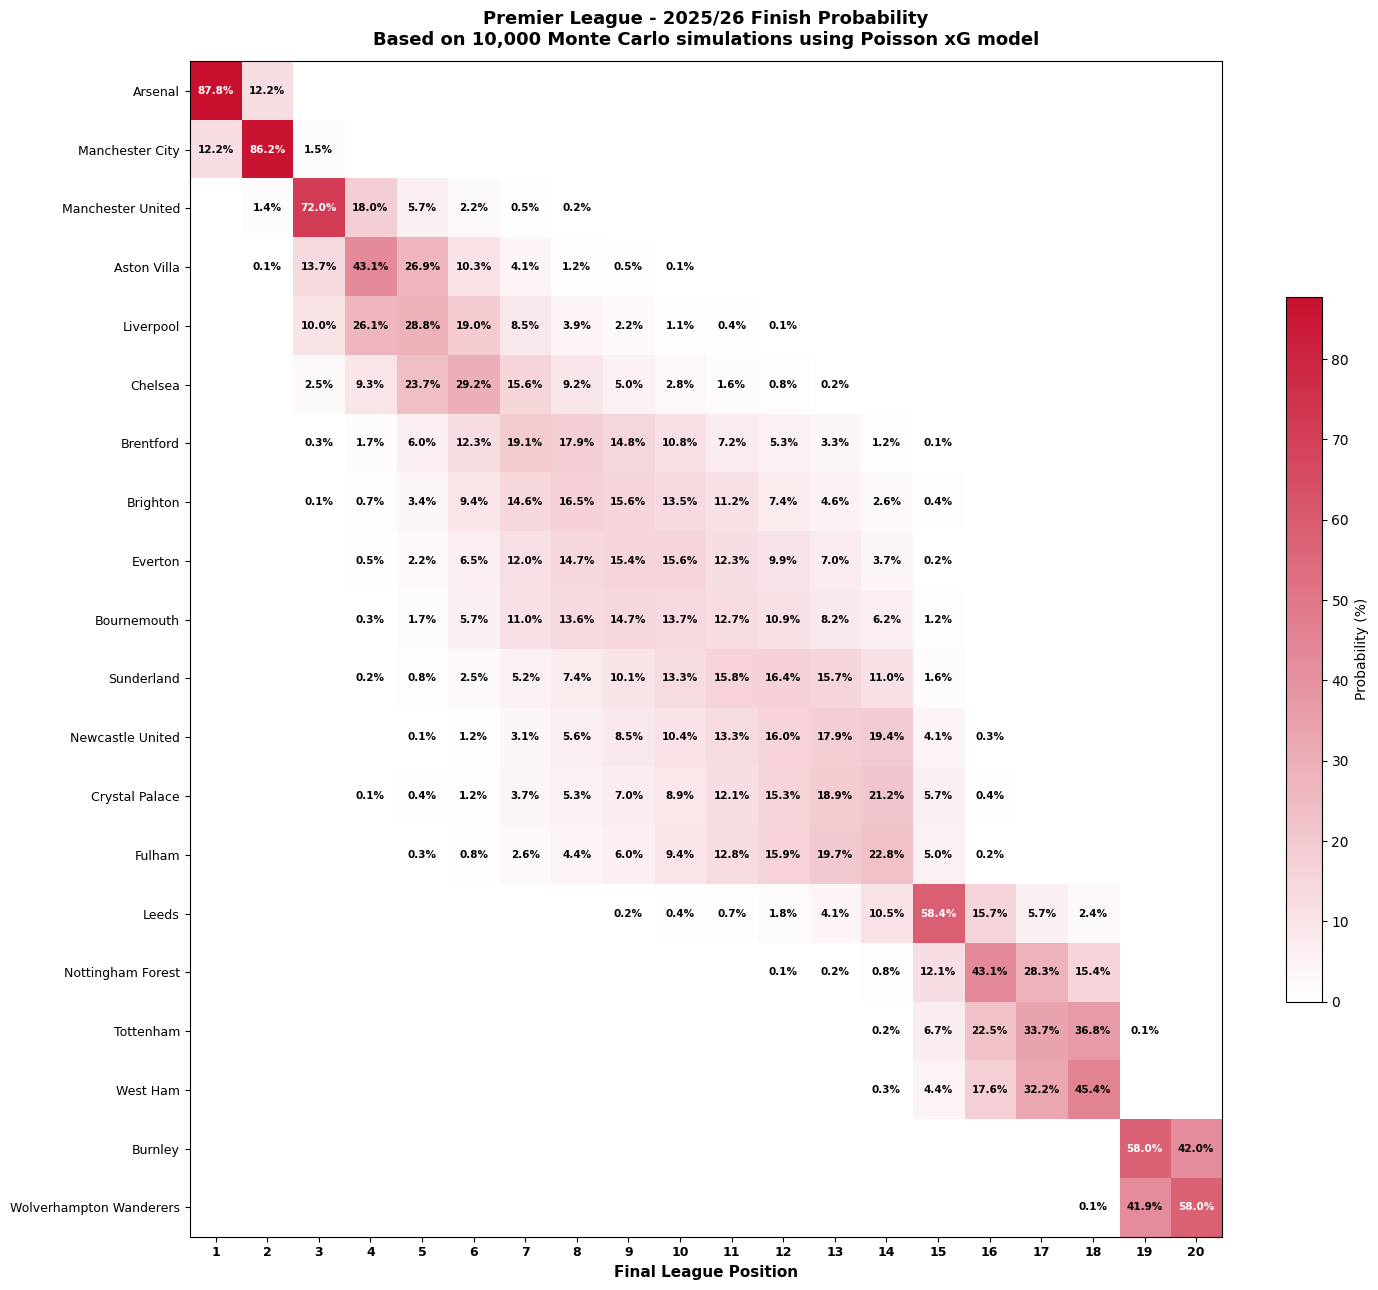

Saved to outputs/monte_carlo_premier_league.png


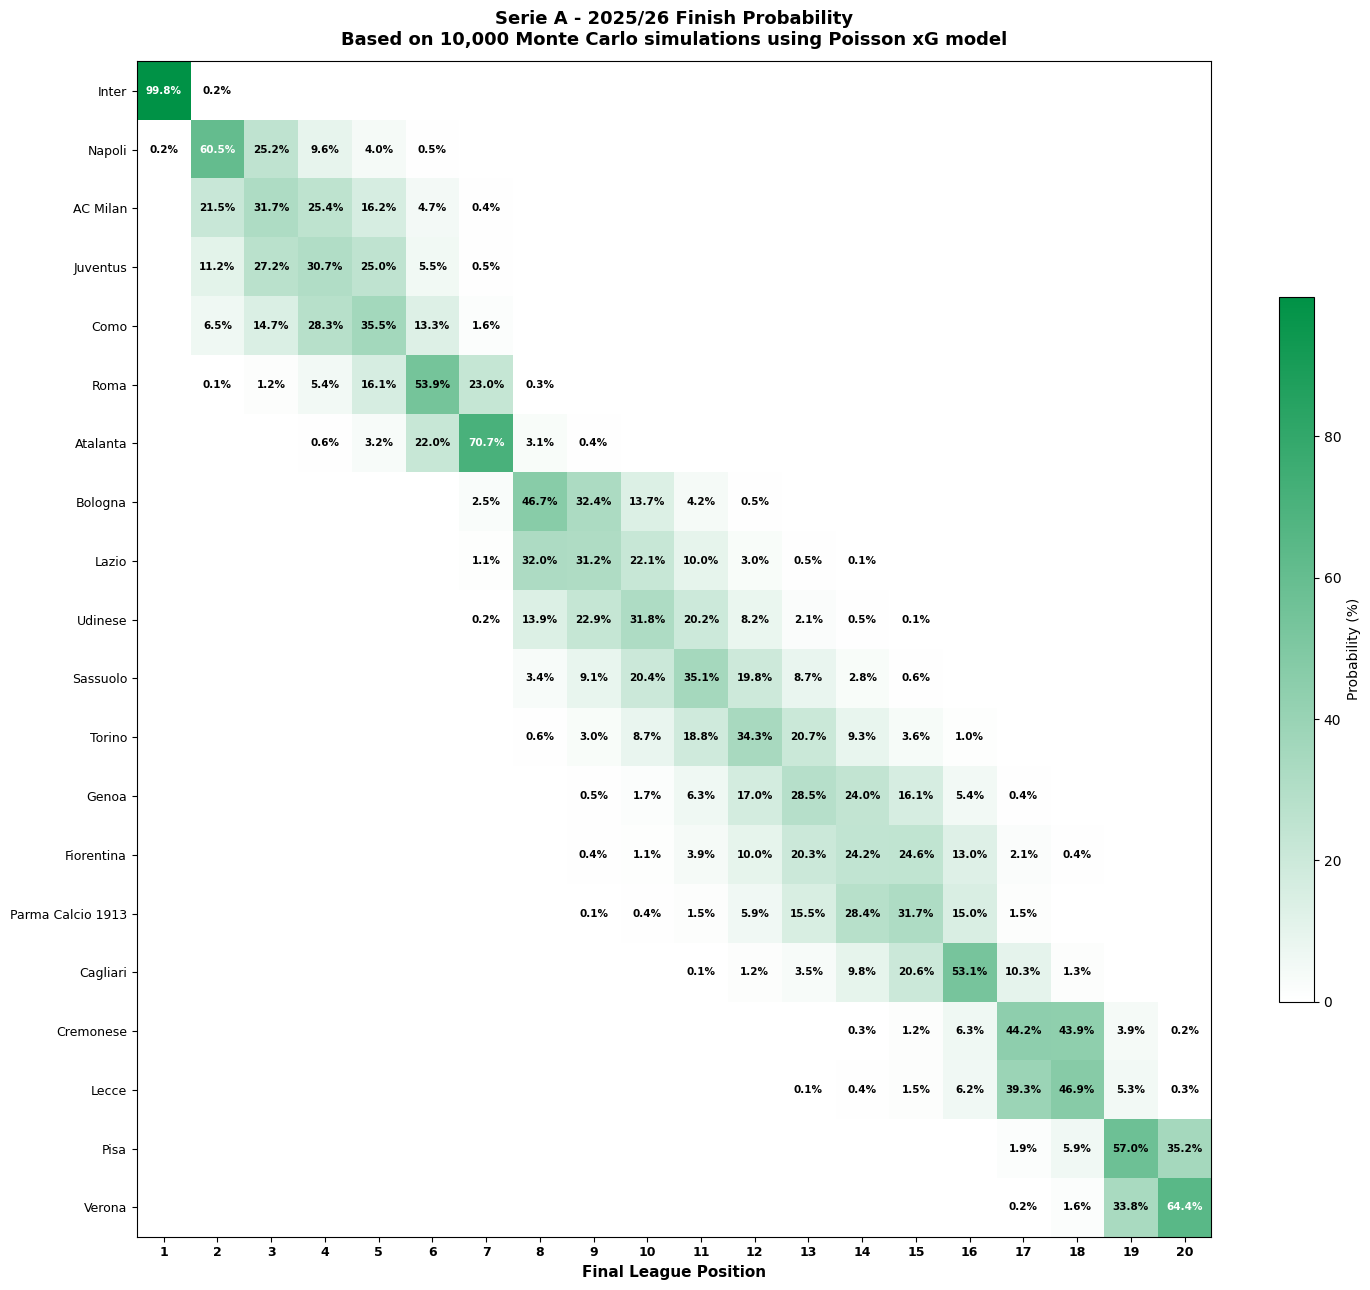

Saved to outputs/monte_carlo_serie_a.png


In [51]:
# Cell 21 - Monte Carlo Heatmap Visualization
# The visual version of the simulation table - inspired by league probability charts

def plot_monte_carlo_heatmap(sim_df, league, color):
    n_teams = len(sim_df)
    pct_df  = (sim_df * 100).round(1)

    fig, ax = plt.subplots(figsize=(max(14, n_teams * 0.75), n_teams * 0.55 + 2))

    cmap = mcolors.LinearSegmentedColormap.from_list(
        'custom', ['#ffffff', color], N=256
    )

    im = ax.imshow(
        pct_df.values,
        cmap=cmap, aspect='auto',
        vmin=0, vmax=pct_df.values.max()
    )

    # Annotate cells
    for i in range(n_teams):
        for j in range(n_teams):
            val = pct_df.values[i, j]
            if val >= 0.1:
                text_color = 'white' if val > pct_df.values.max() * 0.6 else 'black'
                ax.text(j, i, f'{val:.1f}%',
                        ha='center', va='center',
                        fontsize=7.5, color=text_color, fontweight='bold')

    ax.set_xticks(range(n_teams))
    ax.set_xticklabels([str(i+1) for i in range(n_teams)],
                       fontsize=9, fontweight='bold')
    ax.set_yticks(range(n_teams))
    ax.set_yticklabels(pct_df.index, fontsize=9)
    ax.set_xlabel('Final League Position', fontsize=11, fontweight='bold')
    ax.set_title(
        f'{league} - 2025/26 Finish Probability\n'
        f'Based on {N_SIMS:,} Monte Carlo simulations using Poisson xG model',
        fontsize=13, fontweight='bold', pad=12
    )

    plt.colorbar(im, ax=ax, label='Probability (%)', shrink=0.6)
    plt.tight_layout()

    filename = f"outputs/monte_carlo_{league.lower().replace(' ', '_')}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved to {filename}')


plot_monte_carlo_heatmap(epl_sim,    'Premier League', '#C8102E')
plot_monte_carlo_heatmap(seriea_sim, 'Serie A',        '#009246')

In [60]:
# Cell 22 - Title, Europe, and Relegation Race Summary
# Extracting headline probabilities for every competitive finish threshold

european_spots = {
    'Premier League': {
        'Champions League': list(range(1, 6)),
        'Europa League':    [6],
        'Conference League':[7],
        'Relegation':       list(range(18, 21))
    },
    'Serie A': {
        'Champions League': list(range(1, 5)),
        'Europa League':    [5],
        'Conference League':[6],
        'Relegation':       list(range(18, 21))
    }
}

def print_race_summary(sim_df, league):
    spots = european_spots[league]
    print(f'\n'+'=' * 40)
    print(f'{league} - 2025/26 Finish Probability Summary')
    print('=' * 40)

    # Title
    title_probs = (sim_df['P1'] * 100).sort_values(ascending=False)
    print('\nLeague Title (1st):')
    for team, prob in title_probs[title_probs >= 0.5].items():
        print(f'  {team:<28} {prob:.1f}%')

    # All other thresholds
    for category, positions in spots.items():
        cols  = [f'P{p}' for p in positions if f'P{p}' in sim_df.columns]
        probs = (sim_df[cols].sum(axis=1) * 100).sort_values(ascending=False)
        pos_label = (f'{positions[0]}' if len(positions) == 1
                     else f'{positions[0]}-{positions[-1]}')
        print(f'\n{category} (Position {pos_label}):')
        cutoff = 3.0 if category == 'Relegation' else 5.0
        for team, prob in probs[probs >= cutoff].items():
            print(f'  {team:<28} {prob:.1f}%')

print_race_summary(epl_sim,    'Premier League')
print_race_summary(seriea_sim, 'Serie A')


Premier League - 2025/26 Finish Probability Summary

League Title (1st):
  Arsenal                      87.8%
  Manchester City              12.2%

Champions League (Position 1-5):
  Arsenal                      100.0%
  Manchester City              100.0%
  Manchester United            97.0%
  Aston Villa                  83.8%
  Liverpool                    64.9%
  Chelsea                      35.5%
  Brentford                    7.9%

Europa League (Position 6):
  Chelsea                      29.1%
  Liverpool                    19.0%
  Brentford                    12.3%
  Aston Villa                  10.3%
  Brighton                     9.4%
  Everton                      6.5%
  Bournemouth                  5.7%

Conference League (Position 7):
  Brentford                    19.1%
  Chelsea                      15.6%
  Brighton                     14.6%
  Everton                      11.9%
  Bournemouth                  11.0%
  Liverpool                    8.5%
  Sunderland       